In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF
from scipy import stats

from numpy.ma.core import mean, sqrt

In [3]:
#set path + read into dataframe
path = r'../rotterdam_dataset_06.xlsx'
rd = pd.read_excel(path)

#rename for easiness
rd = rd.rename(columns = {'Arrival_Date': 'arrival_date','Vessel_ID':'vessel_id','Vessel_Type':'vessel_type', 'Cargo_tons':'cargo_tons',
                         'Berth_Time_hr':'berth_time_hr'})

# + seaborn style
sns.set_theme(style = 'darkgrid')
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')

## Arrival Rates (month/day)

In [4]:
#setting up new cols for easy filtering later
rd['year_month_day'] = rd['arrival_date'].dt.strftime('%Y-%m-%d')
rd['year_month'] = rd['arrival_date'].dt.strftime('%Y-%m')
rd['year'] = rd['arrival_date'].dt.strftime('%Y')
rd['month_day'] = rd['arrival_date'].dt.strftime('%m-%d')

#setup grouping for analysis
year_month_count = rd['year_month'].groupby(rd['year_month']).count()
year_month_day_count = rd['year_month_day'].groupby(rd['year_month_day']).count()

In [5]:
print(year_month_count.describe())

#check where min/max are (true/false depending)
#print(rd['year_month'].groupby(rd['year_month']).count().sort_values(ascending = True))
type(year_month_count)

count     36.000000
mean     545.194444
std       78.020444
min      420.000000
25%      484.750000
50%      518.000000
75%      610.250000
max      689.000000
Name: year_month, dtype: float64


pandas.Series

In [6]:
#outlier function from dataquality.py, edited for series-handling
def find_outlier(cont_attr: str, rd = rd):
    '''find outliers via q3/q1 method

    args:
    cont_attr: str - continuous attribute name
    rd: dataframe - rotterdam data; default

    returns:
    outlier: dataframe of outliers
    above_outlier: dataframe of outliers above q3
    below_outlier: dataframe of outliers below q1
    '''
    q3 = rd.quantile(0.75)
    q1 = rd.quantile(0.25)

    #outlier = val>q3 or val<q1
    outlier = rd[(rd > q3) | (rd < q1)]

    #completeness-sake: add above/below outliers to check for inconsistencies
    above_outlier = rd[rd > q3]
    below_outlier = rd[rd < q1]
    
    return outlier, above_outlier, below_outlier

outlier_month, large_outlier_month, small_outlier_month = find_outlier('year_month_count', year_month_count)
outlier_day, large_outlier_day, small_outlier_day = find_outlier('year_month_day_count', year_month_day_count)

In [7]:
print(year_month_day_count.describe())
#avg, median, variance, and std PER DAY
avg_arrival_day = year_month_day_count.mean()
med_arrival_day = year_month_day_count.median()
std_arrival_day = year_month_day_count.std()

#check where min/max are + other suspicious vals
#print(year_month_day_count.sort_values(ascending = True))

count    1096.000000
mean       17.907847
std         4.833076
min         4.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        35.000000
Name: year_month_day, dtype: float64


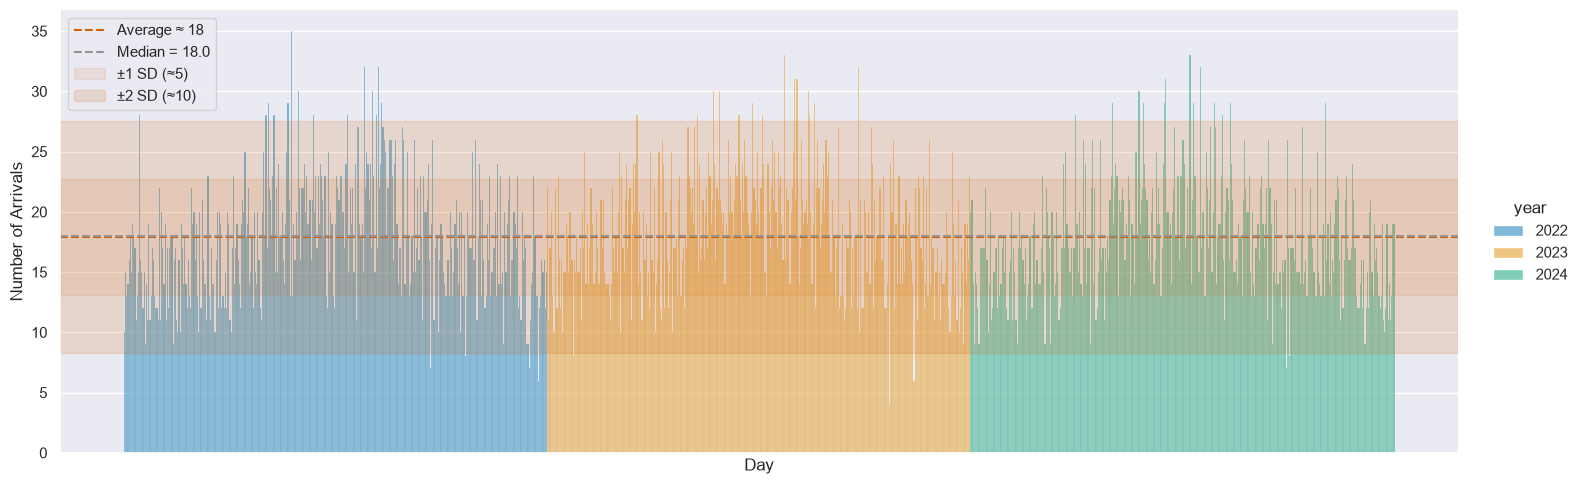

In [8]:
#histogram of per day vessel calls
h = sns.displot(data = rd, x = 'year_month_day', hue = 'year', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

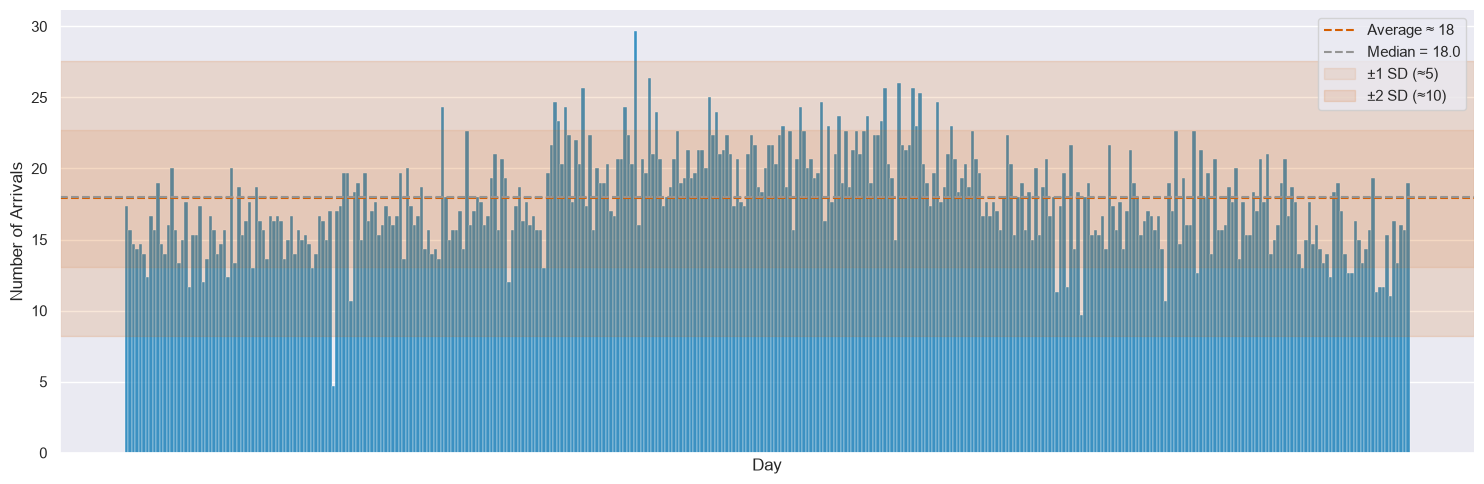

In [9]:
#histogram of per day vessel calls
h = sns.displot(data = rd.sort_values('month_day').assign(w = 1/3), x = 'month_day',
                weights = 'w', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

## Arrival rates + vessel types

In [10]:
#filter for vessel types
print(rd['vessel_type'].unique())

#first filter for vessel type, then group by for stats x3
container = rd[rd['vessel_type'] == 'Container']
container_day_count = container['year_month_day'].groupby(container['year_month_day']).count()

tanker = rd[rd['vessel_type'] == 'Tanker']
tanker_day_count = tanker['year_month_day'].groupby(tanker['year_month_day']).count()

bulk = rd[rd['vessel_type'] == 'Bulk']
bulk_day_count = bulk['year_month_day'].groupby(bulk['year_month_day']).count()


<StringArray>
['Container', 'Tanker', 'Bulk']
Length: 3, dtype: str


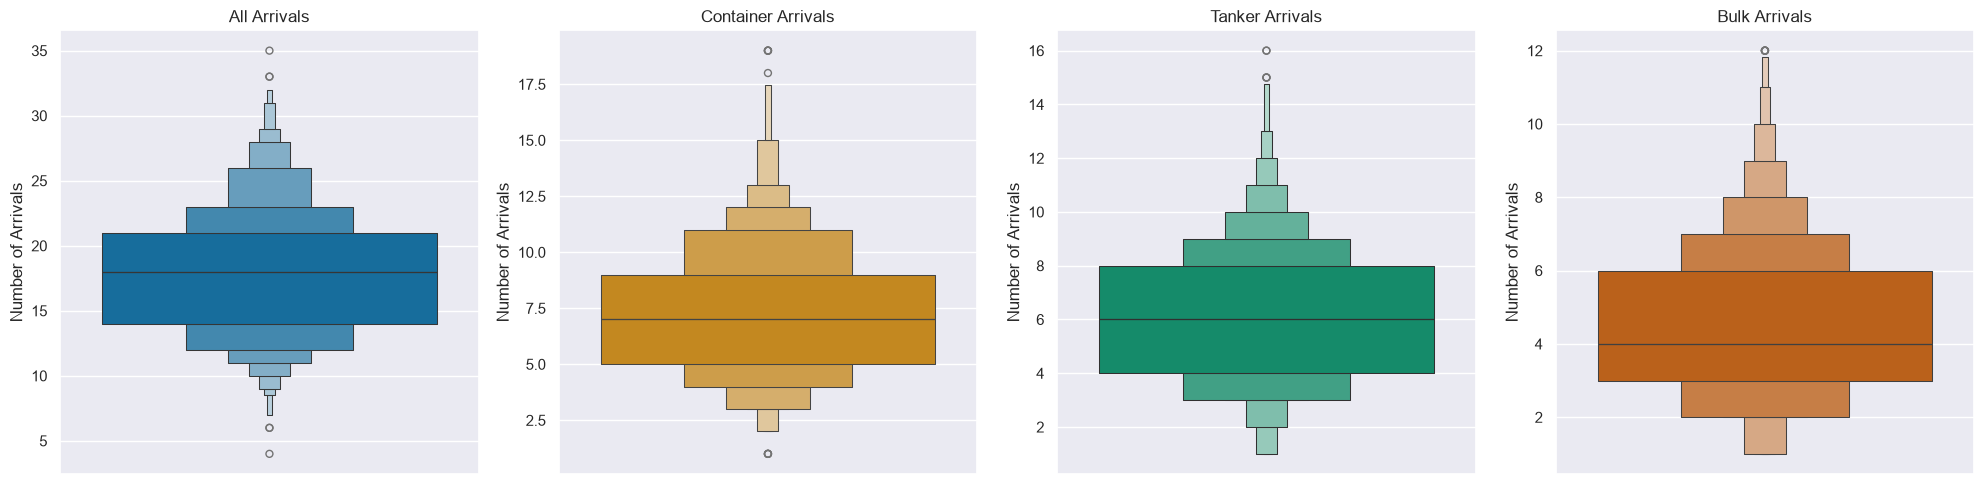

In [11]:
#plots next to each other despite diff scale b/c need space on report
f, ax = plt.subplots(1, 4, figsize = (20, 5))

#boxenplots good for large datasets
sns.boxenplot(y = year_month_day_count, ax = ax[0], color = palette[0])
ax[0].set_title('All Arrivals')
ax[0].set_ylabel('Number of Arrivals')

sns.boxenplot(y = container_day_count, ax = ax[1], color = palette[1])
ax[1].set_title('Container Arrivals')
ax[1].set_ylabel('Number of Arrivals')

sns.boxenplot(y = tanker_day_count, ax = ax[2], color = palette[2])
ax[2].set_title('Tanker Arrivals')
ax[2].set_ylabel('Number of Arrivals')

sns.boxenplot(y = bulk_day_count, ax = ax[3], color = palette[3])
ax[3].set_title('Bulk Arrivals')
ax[3].set_ylabel('Number of Arrivals')

#save/layout
plt.tight_layout()
plt.savefig('figures/arrivalsbox.jpeg', bbox_inches='tight')
plt.show()

In [12]:
print(container_day_count.mean())
print(tanker_day_count.mean())
print(bulk_day_count.mean())

7.3713503649635035
6.15032080659945
4.513059701492537


## Inter-Arrival Rates

In [13]:
arrival = rd['arrival_date'].sort_values()

#convert each date into hours since first arrival
#arrival-arrival = dt then total seconds b/c lowest value then into hours
arrival_time = (arrival - arrival.iloc[0]).dt.total_seconds() / 3600

#np from lecture
inter_arrival_times = np.diff(arrival_time)

In [14]:
def vessel_inter(vessel:str, rd = rd):
    '''filter rd on vessel type and return inter_arrival times for that vessel

    args:
    vessel: str - vessel type
    rd: df - original, default

    return:
    inter_arrival_times: numpy array
    '''
    vessel_filter = rd[rd['vessel_type'] == vessel]
    
    #sort values to get the first arrival 
    arrival = vessel_filter['arrival_date'].sort_values()
    
    #arrival-firstarrival = dt then convert to total seconds from first arrival -> hour
    arrival_time = (arrival - arrival.iloc[0]).dt.total_seconds() / 3600

    #from lecture, difference
    inter_arrival_times = np.diff(arrival_time)
    return inter_arrival_times

container = vessel_inter('Container')
bulk = vessel_inter('Bulk')
tanker = vessel_inter('Tanker')

In [25]:
def method_of_moments(array):
    '''take array, get method of moments exponential

    args:
    array: numpy array (of interarrival times)

    return:
    samplemean: sample mean of array
    parameter: calculation for exponential lambda
    '''
    
    samplemean = mean(array)
    param = 1/samplemean
    return samplemean, param

In [26]:
sample_cont, param_cont = method_of_moments(container)
sample_bulk, param_bulk = method_of_moments(bulk)
sample_tank, param_tank = method_of_moments(tanker)

#lambda per hour
print(f'container interarrival time ~ exp({param_cont})')
print(f'bulk interarrival time ~ exp({param_bulk})')
print(f'tanker interarrival time ~ exp({param_tank})')

container interarrival time ~ exp(0.3073319480526069)
bulk interarrival time ~ exp(0.18403472449008712)
tanker interarrival time ~ exp(0.25524710537328954)


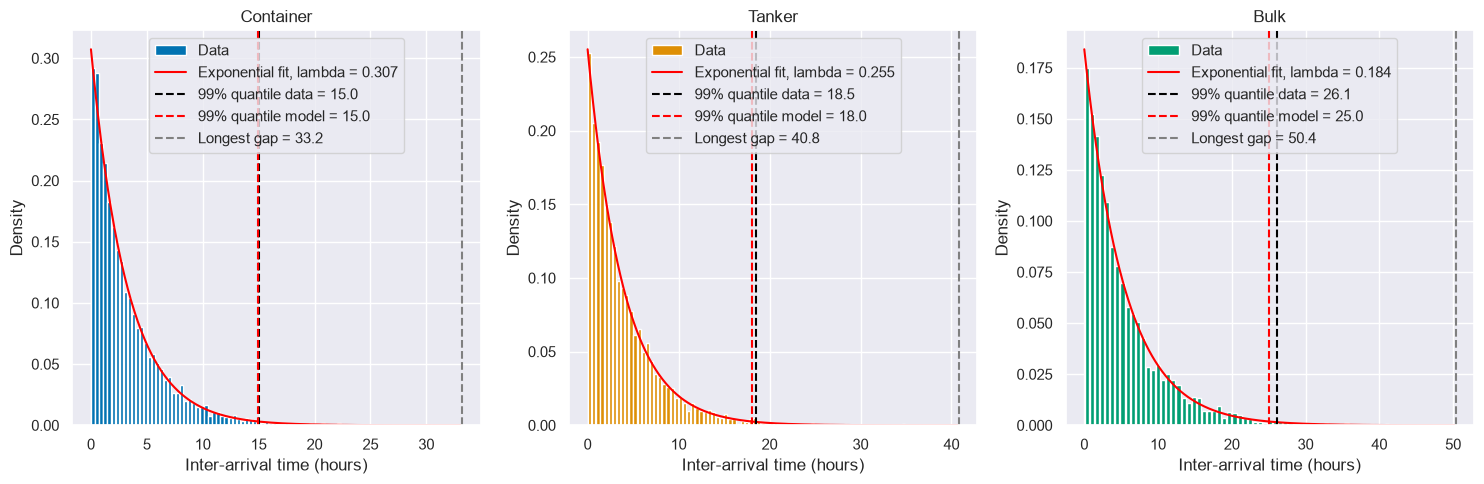

In [36]:
#fitted exponential distributions (from method_of_moments)
fitExpDist_C = stats.expon(scale = 1/param_cont)
fitExpDist_T = stats.expon(scale = 1/param_tank)
fitExpDist_B = stats.expon(scale = 1/param_bulk)

#extreme observations; 99% quant
q99_C = np.quantile(container, 0.99)
q99_T = np.quantile(tanker, 0.99)
q99_B = np.quantile(bulk, 0.99)

#99% quantiles of the model, P(X > x) = exp(-lambda*x) = 0.01, so x = -ln(0.01)/lambda
q99model_C = -np.log(0.01) / param_cont
q99model_T = -np.log(0.01) / param_tank
q99model_B = -np.log(0.01) / param_bulk


f, ax = plt.subplots(1, 3, figsize = (15, 5))

ax[0].hist(container, bins = 'auto', rwidth = 0.8, density = True, color = palette[0], label = 'Data')
xs = np.arange(0, np.max(container), 0.1)
ys = fitExpDist_C.pdf(xs)
ax[0].plot(xs, ys, color = 'red', label = 'Exponential fit, lambda = ' + str(round(param_cont, 3)))
ax[0].axvline(q99_C, color = 'black', linestyle = '--', label = '99% quantile data = ' + str(round(q99_C, 1)))
ax[0].axvline(q99model_C, color = 'red', linestyle = '--', label = '99% quantile model = ' + str(round(q99model_C, 1)))
ax[0].axvline(np.max(container), color = 'grey', linestyle = '--', label = 'Longest gap = ' + str(round(np.max(container), 1)))
ax[0].set_title('Container')
ax[0].set_xlabel('Inter-arrival time (hours)')
ax[0].set_ylabel('Density')
ax[0].legend()

ax[1].hist(tanker, bins = 'auto', rwidth = 0.8, density = True, color = palette[1], label = 'Data')
xs = np.arange(0, np.max(tanker), 0.1)
ys = fitExpDist_T.pdf(xs)
ax[1].plot(xs, ys, color = 'red', label = 'Exponential fit, lambda = ' + str(round(param_tank, 3)))
ax[1].axvline(q99_T, color = 'black', linestyle = '--', label = '99% quantile data = ' + str(round(q99_T, 1)))
ax[1].axvline(q99model_T, color = 'red', linestyle = '--', label = '99% quantile model = ' + str(round(q99model_T, 1)))
ax[1].axvline(np.max(tanker), color = 'grey', linestyle = '--', label = 'Longest gap = ' + str(round(np.max(tanker), 1)))
ax[1].set_title('Tanker')
ax[1].set_xlabel('Inter-arrival time (hours)')
ax[1].set_ylabel('Density')
ax[1].legend()

ax[2].hist(bulk, bins = 'auto', rwidth = 0.8, density = True, color = palette[2], label = 'Data')
xs = np.arange(0, np.max(bulk), 0.1)
ys = fitExpDist_B.pdf(xs)
ax[2].plot(xs, ys, color = 'red', label = 'Exponential fit, lambda = ' + str(round(param_bulk, 3)))
ax[2].axvline(q99_B, color = 'black', linestyle = '--', label = '99% quantile data = ' + str(round(q99_B, 1)))
ax[2].axvline(q99model_B, color = 'red', linestyle = '--', label = '99% quantile model = ' + str(round(q99model_B, 1)))
ax[2].axvline(np.max(bulk), color = 'grey', linestyle = '--', label = 'Longest gap = ' + str(round(np.max(bulk), 1)))
ax[2].set_title('Bulk')
ax[2].set_xlabel('Inter-arrival time (hours)')
ax[2].set_ylabel('Density')
ax[2].legend()

plt.tight_layout()
plt.savefig('figures/interarrival_hist.jpeg', bbox_inches = 'tight')
plt.show()

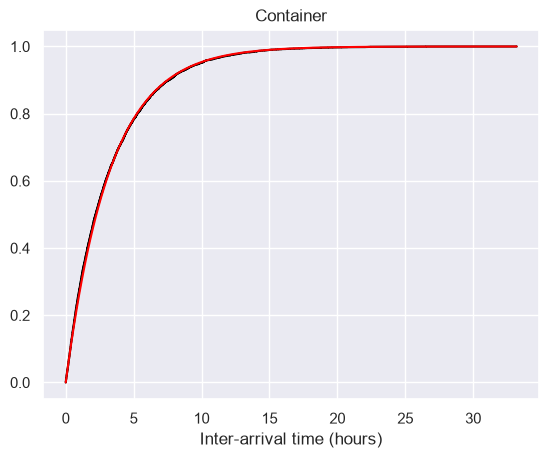

KS Test Exponential Container KstestResult(statistic=np.float64(0.01652923307076659), pvalue=np.float64(0.02394274185684265), statistic_location=np.float64(1.2333333333335759), statistic_sign=np.int8(1))


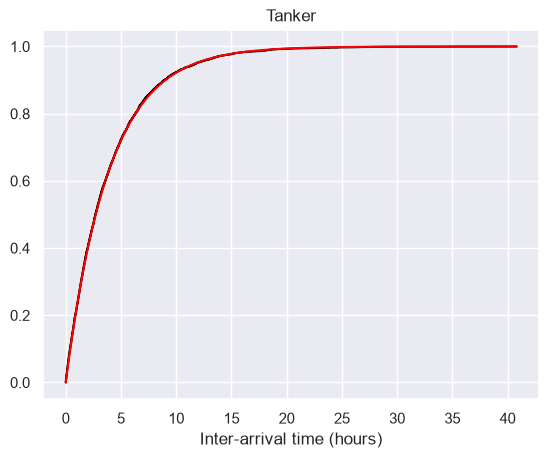

KS Test Exponential Tanker KstestResult(statistic=np.float64(0.008800370213765223), pvalue=np.float64(0.6729402594335159), statistic_location=np.float64(0.21666666666715173), statistic_sign=np.int8(1))


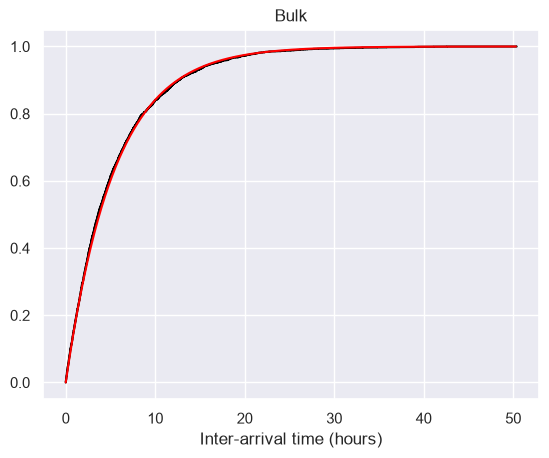

KS Test Exponential Bulk KstestResult(statistic=np.float64(0.015420361382600833), pvalue=np.float64(0.19819944765532116), statistic_location=np.float64(3.8000000000029104), statistic_sign=np.int8(1))


In [21]:
#goodness of fit, ECDF + Kolmogorov-Smirnov test
def exp_fit_test(array, vessel: str):
    lam = 1 / np.mean(array)
    fitExpDist = stats.expon(scale = 1/lam)

    #ecdf vs fitted cdf
    xs = np.arange(0, np.max(array), 0.1)
    ecdf = ECDF(array)
    plt.figure()
    plt.step(ecdf.x, ecdf.y, color = 'black', where = 'post')
    plt.plot(xs, fitExpDist.cdf(xs), color = 'red')
    plt.title(vessel)
    plt.xlabel('Inter-arrival time (hours)')
    plt.show()

    #Kolmogorov-Smirnov test
    tst = stats.kstest(array, fitExpDist.cdf)
    print(f'KS Test Exponential {vessel} {str(tst)}')

exp_fit_test(container, 'Container')
exp_fit_test(tanker, 'Tanker')
exp_fit_test(bulk, 'Bulk')